# Diabetes Prediction — Binary Classification Pipeline
### 281K Patient Dataset for Multi-Disease Prediction

---

## 📌 Objective
The primary objective of this project is to build, evaluate, and compare classical and ensemble machine learning models to predict **diabetes status** using a large, multi-disease patient dataset. 

In a healthcare screening context, missing a positive case can have severe consequences. Therefore, this pipeline places a critical emphasis on **recall** to minimize false negatives.

---

## 🛠 Pipeline Overview

1. **Environment Setup & Library Imports**  
   Loading essential Python libraries for data manipulation, visualization, and machine learning modeling.

2. **Data Loading & Target Inspection**  
   Importing the dataset and analyzing the distribution of the target variable to check for class imbalances.

3. **Feature Selection & Leakage-Safe Column Dropping**  
   Identifying highly correlated features or columns that contain future information to prevent data leakage.

4. **Preprocessing & Categorical Encoding**  
   Converting categorical variables into numerical formats using safe encoding practices.

5. **Train/Test Split & Feature Scaling**  
   Dividing the dataset into training and testing subsets, followed by applying normalization or standardization to numerical features.

6. **Model Training**  
   Training multiple classifiers, including **Logistic Regression**, **Random Forest**, and **XGBoost**.

7. **Evaluation & Visualization**  
   Assessing model performance through comprehensive evaluation metrics, including:
   * Classification reports (Precision, Recall, F1-score)
   * Confusion matrices
   * ROC-AUC curves

8. **Model Persistence**  
   Exporting the trained model using `pickle` to prepare it for deployment in a downstream **Streamlit web application**.

---

## 👤 Author & Links

* **Author:** ABXREHMAN
* **GitHub:** [datawithabdulrehman](https://github.com)
* **Kaggle:** [datawithabxrehman](https://kaggle.com)
* **LinkedIn:** [datawithabdulrehman](https://linkedin.com)


## 1. Environment Setup & Libraries

We import all core libraries up front:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualization
- **scikit-learn** — preprocessing, splitting, and evaluation metrics
- **XGBoost** — gradient boosting classifier

We also set a global `RANDOM_STATE` for full reproducibility across the notebook.


In [1]:
# ==============================
# Core data handling & numerics
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Preprocessing & model selection
# ==============================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ==============================
# Evaluation metrics
# ==============================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ==============================
# Machine Learning models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==============================
# Persistence
# ==============================
import pickle

# ==============================
# Global config
# ==============================
RANDOM_STATE = 42
TARGET_COL = "diabetes"

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Reproducibility
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Data Loading & Target Inspection

We load the dataset and immediately inspect its shape, schema, and the balance of the target
variable `diabetes`. Understanding class imbalance up front is essential — it directly informs
whether we need `class_weight='balanced'`, stratified splitting, or resampling strategies later.


In [2]:
# Load the FULL dataset — no nrows limit, no head()/slice truncation
DATA_PATH = "/content/Data Warehouse Multiclass.csv"
df = pd.read_csv(DATA_PATH)

print(f"Full dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

# IMPORTANT: this dataset is grouped/sorted by composite_key, meaning the target
# label is clustered in contiguous blocks (all-'No' rows, then all-'Yes' rows, etc.).
# If you ever slice, sample, or preview the file without shuffling first, you can
# end up with a single-class subset -> models will fail with
# "needs samples of at least 2 classes". We shuffle immediately to guard against this.
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df.info()


Full dataset shape: 45,350 rows x 39 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45350 entries, 0 to 45349
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   composite_key         45350 non-null  object 
 1   age_level             45350 non-null  object 
 2   gender                45350 non-null  object 
 3   bmi_level             45350 non-null  object 
 4   smoking               45350 non-null  object 
 5   diabetes              45350 non-null  object 
 6   age                   45350 non-null  int64  
 7   age_normalized        45350 non-null  float64
 8   bmi                   45350 non-null  float64
 9   hypertension          45350 non-null  int64  
 10  heart_disease         45350 non-null  int64  
 11  HbA1c_level           45350 non-null  float64
 12  glucose               45350 non-null  int64  
 13  cholesterol           45350 non-null  float64
 14  sleep_hours           45

In [3]:
# Preview the first few rows
df.head()


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Underweight_Never_No,Young,Female,Underweight,Never,No,6,0.045977,16.60,0,...,8.146809,77.304965,64.078014,134.453901,Tertiary,Retired,diabetes,"0,0,0",N,Normal
1,Mature_Female_Overweight_Current_No,Mature,Female,Overweight,Current,No,52,0.574713,26.96,0,...,8.274740,74.458420,65.126819,128.726611,Secondary,Retired,diabetes,"0,0,0",N,Normal
2,Mature_Female_Obese_Never_No,Mature,Female,Obese,Never,No,51,0.563218,37.10,0,...,8.466478,74.754963,64.573454,128.362450,Tertiary,Retired,diabetes,"0,0,0",N,Normal
3,Middle_Female_Obese_Former_No,Middle,Female,Obese,Former,No,45,0.494253,33.75,0,...,8.628292,74.513602,64.744287,128.557127,Primary,Unemployed,diabetes,"0,0,0",N,Normal
4,Mature_Female_Overweight_Current_No,Mature,Female,Overweight,Current,No,48,0.528736,27.32,1,...,8.274740,74.458420,65.126819,128.726611,Secondary,Retired,diabetes,"0,0,1",HY,Abnormal


In [4]:
# Fresh, isolated read — completely independent of any prior df in memory
_raw_check = pd.read_csv("/content/Data Warehouse Multiclass.csv", usecols=["diabetes"])
print("Fresh raw dtype:", _raw_check["diabetes"].dtype)
print("Fresh raw unique values:")
for v in _raw_check["diabetes"].unique():
    print(repr(v))
print()
print(_raw_check["diabetes"].value_counts(dropna=False))

Fresh raw dtype: object
Fresh raw unique values:
'No'
'Yes'

diabetes
No     43229
Yes     2121
Name: count, dtype: int64


Raw unique values in target column: ['No' 'Yes']
Raw target value counts:
diabetes
No     43229
Yes     2121
Name: count, dtype: int64

Target encoded successfully (0 = No, 1 = Yes):
diabetes
0    43229
1     2121
Name: count, dtype: int64

Target class proportions (%):
diabetes
0    95.32
1     4.68
Name: proportion, dtype: float64


/tmp/ipykernel_2377/3326449624.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET_COL, data=df, ax=ax, palette=["#4C72B0", "#DD8452"])


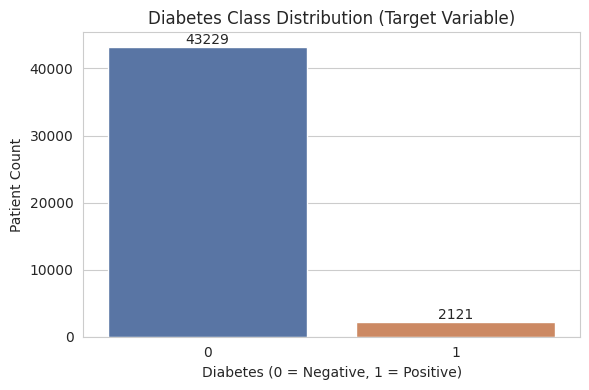

In [5]:
# Raw target values (before encoding)
print("Raw unique values in target column:", df[TARGET_COL].unique())
print("Raw target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

# --- Explicit target encoding: map 'Yes'/'No' strings to 1/0 ---
# (Handles stray whitespace/casing defensively before mapping.)
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.capitalize()
df[TARGET_COL] = df[TARGET_COL].map({"No": 0, "Yes": 1})

# Hard safety check: fail loudly here rather than deep inside model.fit() later
assert df[TARGET_COL].isnull().sum() == 0, (
    "Target mapping produced NaNs -- check for unexpected values "
    f"(found: {df[TARGET_COL].unique()}) besides 'Yes'/'No'."
)
assert df[TARGET_COL].nunique() == 2, (
    f"Target still has {df[TARGET_COL].nunique()} class(es) after mapping: "
    f"{df[TARGET_COL].unique()}. The source CSV may be missing one class entirely."
)

print("\nTarget encoded successfully (0 = No, 1 = Yes):")
print(df[TARGET_COL].value_counts())
print()
print("Target class proportions (%):")
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

# Visualize class imbalance
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=TARGET_COL, data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("Diabetes Class Distribution (Target Variable)")
ax.set_xlabel("Diabetes (0 = Negative, 1 = Positive)")
ax.set_ylabel("Patient Count")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


In [6]:
# Quick summary of missing values across the dataset
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if missing_summary.empty:
    print("No missing values detected in the raw dataset.")
else:
    print("Columns with missing values:")
    print(missing_summary)


Columns with missing values:
physical_activity       1
family_history          1
stress_level            1
low_hdl_cholesterol     1
high_ldl_cholesterol    1
blood_pressure          1
high_blood_pressure     1
sugar_consumption       1
crp_level               1
homocysteine_level      1
systolic_bp             1
diastolic_bp            1
alcohol_intake          1
salt_intake             1
heart_rate              1
hdl                     1
ldl                     1
education_level         1
employment_status       1
source_dataset          1
disease_flags           1
sublabel                1
label                   1
dtype: int64


## 3. Feature Selection & Drop Logic

Before modeling, we must remove columns that either:
- Carry **no predictive signal** (e.g., unique identifiers like `composite_key`), or
- **Leak the target** — columns derived from or highly entangled with disease labels
  (e.g., `disease_flags`, `sublabel`, `label`), or
- Represent **other diagnosed conditions** (`hypertension`, `heart_disease`) that would not
  realistically be known *in advance* of a diabetes screening in a real deployment scenario, or
- Identify dataset **provenance** rather than patient physiology (`source_dataset`).

Dropping these prevents data leakage and keeps the model honest about what it can actually infer
from clinically available features.


In [7]:
# Columns to drop: identifiers, leakage-prone labels, and non-predictive metadata
COLUMNS_TO_DROP = [
    "composite_key",
    "hypertension",
    "heart_disease",
    "disease_flags",
    "sublabel",
    "label",
    "source_dataset",
]

# Only drop columns that actually exist in the dataframe (defensive coding)
existing_drop_cols = [c for c in COLUMNS_TO_DROP if c in df.columns]
missing_drop_cols = [c for c in COLUMNS_TO_DROP if c not in df.columns]

if missing_drop_cols:
    print(f"Note: these expected drop-columns were not found in the dataset: {missing_drop_cols}")

df_model = df.drop(columns=existing_drop_cols)
print(f"Dropped columns: {existing_drop_cols}")
print(f"Remaining shape: {df_model.shape}")


Dropped columns: ['composite_key', 'hypertension', 'heart_disease', 'disease_flags', 'sublabel', 'label', 'source_dataset']
Remaining shape: (45350, 32)


In [8]:
# Isolate target vector and feature matrix
y = df_model[TARGET_COL].copy()
X = df_model.drop(columns=[TARGET_COL]).copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")


Feature matrix X shape: (45350, 31)
Target vector y shape:  (45350,)

Feature columns:
['age_level', 'gender', 'bmi_level', 'smoking', 'age', 'age_normalized', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status']


## 4. Preprocessing & Encoding

This section handles two responsibilities:

1. **Missing value imputation** — numerical columns are imputed with the **median** (robust to
   outliers), categorical columns with the **mode** (most frequent category).
2. **Categorical encoding** — object/string columns (e.g., `gender`, `smoking`, `age_level`,
   `bmi_level`, `education_level`, `employment_status`) are automatically detected and encoded
   using `LabelEncoder`. Encoders are stored in a dictionary so they can be reused/inspected later
   (and optionally persisted for deployment-time consistency).

> **Note:** `LabelEncoder` is used here for simplicity and to keep the feature space compact,
> which works well for tree-based models (Random Forest, XGBoost) and is acceptable for Logistic
> Regression given these are largely ordinal/binary-like categorical fields. For strictly nominal
> high-cardinality features, `pd.get_dummies` (one-hot encoding) would be preferred instead.


In [9]:
# Automatically identify categorical (object/string) vs numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")


Categorical columns (13): ['age_level', 'gender', 'bmi_level', 'smoking', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status']
Numerical columns (18): ['age', 'age_normalized', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']


In [10]:
# --- Missing value imputation ---

# Numerical columns -> median imputation
num_missing = X[numerical_cols].isnull().sum()
num_missing = num_missing[num_missing > 0]
if not num_missing.empty:
    print("Imputing numerical columns with median:")
    print(num_missing)
    for col in num_missing.index:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
else:
    print("No missing values in numerical columns.")

# Categorical columns -> mode imputation
cat_missing = X[categorical_cols].isnull().sum()
cat_missing = cat_missing[cat_missing > 0]
if not cat_missing.empty:
    print("\nImputing categorical columns with mode:")
    print(cat_missing)
    for col in cat_missing.index:
        mode_val = X[col].mode()[0]
        X[col] = X[col].fillna(mode_val)
else:
    print("No missing values in categorical columns.")


Imputing numerical columns with median:
blood_pressure        1
crp_level             1
homocysteine_level    1
systolic_bp           1
diastolic_bp          1
alcohol_intake        1
salt_intake           1
heart_rate            1
hdl                   1
ldl                   1
dtype: int64

Imputing categorical columns with mode:
physical_activity       1
family_history          1
stress_level            1
low_hdl_cholesterol     1
high_ldl_cholesterol    1
high_blood_pressure     1
sugar_consumption       1
education_level         1
employment_status       1
dtype: int64


In [11]:
# --- Categorical encoding (LabelEncoder) ---
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': {list(le.classes_)} -> {list(range(len(le.classes_)))}")

print("\nAll categorical columns encoded. Feature matrix is now fully numeric.")
X.head()


Encoded 'age_level': ['Mature', 'Middle', 'Senior', 'Young'] -> [0, 1, 2, 3]
Encoded 'gender': ['Female', 'Male'] -> [0, 1]
Encoded 'bmi_level': ['Normal', 'Obese', 'Overweight', 'Underweight'] -> [0, 1, 2, 3]
Encoded 'smoking': ['Current', 'Former', 'Never'] -> [0, 1, 2]
Encoded 'physical_activity': ['High', 'Low', 'Moderate'] -> [0, 1, 2]
Encoded 'family_history': ['No', 'Yes'] -> [0, 1]
Encoded 'stress_level': ['High', 'Low', 'Medium'] -> [0, 1, 2]
Encoded 'low_hdl_cholesterol': ['No', 'Yes'] -> [0, 1]
Encoded 'high_ldl_cholesterol': ['No', 'Yes'] -> [0, 1]
Encoded 'high_blood_pressure': ['No', 'Yes'] -> [0, 1]
Encoded 'sugar_consumption': ['High', 'Low', 'Medium'] -> [0, 1, 2]
Encoded 'education_level': ['Primary', 'Secondary', 'Tertiary'] -> [0, 1, 2]
Encoded 'employment_status': ['Employed', 'Retired', 'Unemployed'] -> [0, 1, 2]

All categorical columns encoded. Feature matrix is now fully numeric.


,age_level,gender,bmi_level,smoking,age,age_normalized,bmi,HbA1c_level,glucose,cholesterol,...,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status
0,3,0,3,2,6,0.045977,16.60,5.7,200,191.666667,...,11.327074,132.964539,92.156028,14.846809,8.146809,77.304965,64.078014,134.453901,2,1
1,0,0,2,0,52,0.574713,26.96,6.5,85,227.207921,...,12.910524,134.235967,89.338877,15.049688,8.274740,74.458420,65.126819,128.726611,1,1
2,0,0,1,2,51,0.563218,37.10,5.7,130,223.070270,...,12.637835,134.102666,89.733976,15.085649,8.466478,74.754963,64.573454,128.362450,2,1
3,1,0,1,1,45,0.494253,33.75,6.2,160,225.297062,...,12.522140,134.999456,89.408052,14.869913,8.628292,74.513602,64.744287,128.557127,0,2
4,0,0,2,0,48,0.528736,27.32,4.8,158,227.207921,...,12.910524,134.235967,89.338877,15.049688,8.274740,74.458420,65.126819,128.726611,1,1


## 5. Data Splitting & Scaling

We perform an **80/20 stratified train-test split** (`stratify=y`) to preserve the original class
ratio in both partitions — important given the class imbalance observed earlier.

`StandardScaler` is then **fit only on the training set** and used to transform both the training
and test sets. This prevents **data leakage**: statistics from the test set must never influence
the scaling parameters (mean/std) used to transform the training data.


In [12]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print()
print("Training set target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Test set target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training set: 36,280 samples
Test set:     9,070 samples

Training set target distribution:
diabetes
0    0.953
1    0.047
Name: proportion, dtype: float64

Test set target distribution:
diabetes
0    0.953
1    0.047
Name: proportion, dtype: float64


In [13]:
# Safety check: confirm both classes are present in train and test splits
assert y_train.nunique() >= 2, f"y_train has only one class: {y_train.unique()}"
assert y_test.nunique() >= 2, f"y_test has only one class: {y_test.unique()}"
print("Class integrity check passed.")
print("y_train class counts:", y_train.value_counts().to_dict())
print("y_test class counts:", y_test.value_counts().to_dict())


Class integrity check passed.
y_train class counts: {0: 34583, 1: 1697}
y_test class counts: {0: 8646, 1: 424}


In [14]:
# Fit scaler on TRAINING data only, then transform both train and test
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling complete. Numerical features standardized (mean=0, std=1) based on training data only.")
X_train_scaled.head()


Scaling complete. Numerical features standardized (mean=0, std=1) based on training data only.


,age_level,gender,bmi_level,smoking,age,age_normalized,bmi,HbA1c_level,glucose,cholesterol,...,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status
9613,3,0,0,2,-1.028787,-1.028787,-0.677462,0.524603,-1.460797,-0.931036,...,-2.161922,1.451469,-0.179847,-0.945383,1.553014,-0.359645,1.371331,-0.506755,0,1
38657,3,0,2,2,-1.626292,-1.626292,0.033429,-0.445888,0.651128,0.287296,...,-0.148696,-0.531486,-0.219019,2.454591,-0.215651,-1.303984,1.584871,1.775660,0,2
40986,3,0,0,2,-0.829618,-0.829618,-0.412620,0.621652,-0.932816,-0.931036,...,-2.161922,1.451469,-0.179847,-0.945383,1.553014,-0.359645,1.371331,-0.506755,0,1
18186,1,0,0,2,0.016848,0.016848,-1.085875,-0.445888,1.707090,-0.149579,...,-0.162942,1.691180,-0.388221,-0.220048,0.744636,0.090462,-0.039614,0.055417,2,2
17592,1,0,1,2,-0.580657,-0.580657,2.092225,0.718701,0.519132,0.380951,...,0.496876,0.067472,-0.436868,-1.102631,0.278702,0.381306,-1.373592,-1.457229,2,2


## 6. Model Training & Comparison

We train three classifiers spanning different modeling paradigms:

| Model | Type | Rationale |
|---|---|---|
| **Logistic Regression** | Linear baseline | Fast, interpretable benchmark |
| **Random Forest** | Bagged ensemble of trees | Captures non-linear interactions, robust to noise |
| **XGBoost** | Gradient-boosted trees | Typically strongest tabular performance, handles imbalance well |

All models use `random_state=42` and `class_weight`/`scale_pos_weight` adjustments where
applicable to account for class imbalance, since **recall on the positive (diabetic) class**
is our primary concern.


In [15]:
# Compute class imbalance ratio for XGBoost's scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative class (0) count: {neg_count:,}")
print(f"Positive class (1) count: {pos_count:,}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")


Negative class (0) count: 34,583
Positive class (1) count: 1,697
scale_pos_weight for XGBoost: 20.379


In [16]:
# --- Model 1: Logistic Regression (baseline) ---
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


In [17]:
# --- Model 2: Random Forest Classifier ---
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train_scaled, y_train)
print("Random Forest trained.")


Random Forest trained.


In [18]:
# --- Model 3: XGBoost Classifier ---
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_clf.fit(X_train_scaled, y_train)
print("XGBoost trained.")


XGBoost trained.


In [19]:
# Collect trained models for iterative evaluation
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf
}
print("Models ready for evaluation:", list(models.keys()))


Models ready for evaluation: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 7. Evaluation & Visualization

For each model we generate:
1. **Classification report** — precision, recall, F1-score per class (recall on class `1` is our
   headline metric, since missing a true diabetic patient is far costlier than a false alarm in a
   screening context).
2. **Confusion matrices** — side-by-side heatmaps for direct visual comparison.
3. **ROC curves** — combined plot with AUC-ROC scores for all three models.


In [20]:
# Generate predictions (labels + probabilities) for every model
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "report": classification_report(y_test, y_pred, output_dict=True),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC Score: {results[name]['roc_auc']:.4f}\n")


  Logistic Regression
              precision    recall  f1-score   support

           0      0.998     0.945     0.971      8646
           1      0.463     0.962     0.625       424

    accuracy                          0.946      9070
   macro avg      0.731     0.954     0.798      9070
weighted avg      0.973     0.946     0.955      9070

ROC-AUC Score: 0.9892

  Random Forest
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      8646
           1      1.000     0.998     0.999       424

    accuracy                          1.000      9070
   macro avg      1.000     0.999     0.999      9070
weighted avg      1.000     1.000     1.000      9070

ROC-AUC Score: 1.0000

  XGBoost
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      8646
           1      1.000     1.000     1.000       424

    accuracy                          1.000      9070
   macro avg      1.000     1.000 

In [21]:
# Summary table: Precision / Recall / F1 / AUC for the positive (diabetic) class
summary_rows = []
for name, res in results.items():
    pos_metrics = res["report"]["1"]
    summary_rows.append({
        "Model": name,
        "Precision (Class 1)": round(pos_metrics["precision"], 3),
        "Recall (Class 1)": round(pos_metrics["recall"], 3),
        "F1-score (Class 1)": round(pos_metrics["f1-score"], 3),
        "ROC-AUC": round(res["roc_auc"], 3)
    })

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["Recall (Class 1)", "ROC-AUC"], ascending=False
).reset_index(drop=True)

print("Model Comparison Summary (sorted by Recall, then ROC-AUC):")
summary_df


Model Comparison Summary (sorted by Recall, then ROC-AUC):


,Model,Precision (Class 1),Recall (Class 1),F1-score (Class 1),ROC-AUC
0,XGBoost,1.000,1.000,1.000,1.000
1,Random Forest,1.000,0.998,0.999,1.000
2,Logistic Regression,0.463,0.962,0.625,0.989


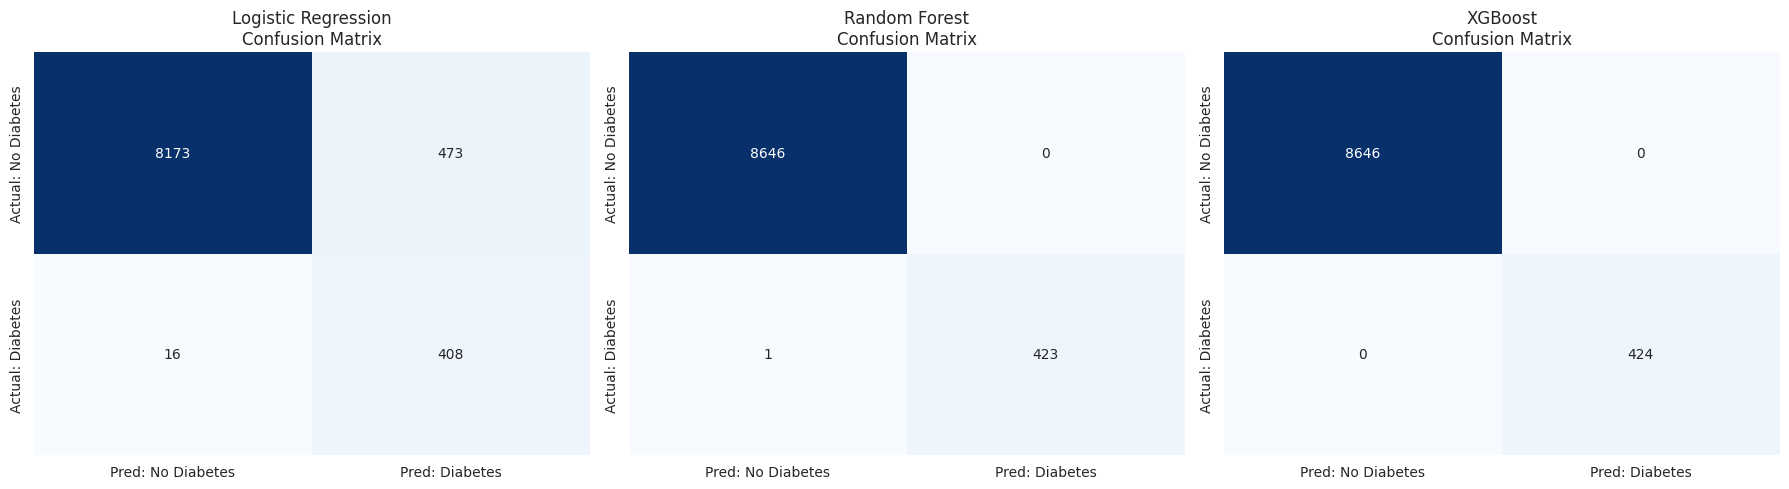

In [22]:
# Side-by-side confusion matrix heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred: No Diabetes", "Pred: Diabetes"],
        yticklabels=["Actual: No Diabetes", "Actual: Diabetes"]
    )
    ax.set_title(f"{name}\nConfusion Matrix")

plt.tight_layout()
plt.show()


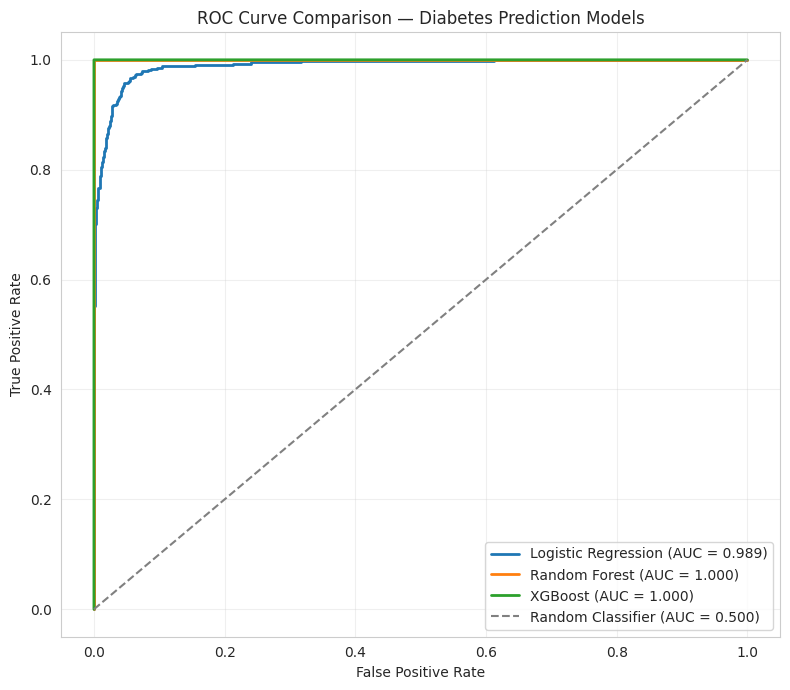

In [23]:
# Combined ROC curve comparison across all three models
fig, ax = plt.subplots(figsize=(8, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})", linewidth=2)

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — Diabetes Prediction Models")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2377/2493735949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")
/tmp/ipykernel_2377/2493735949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")


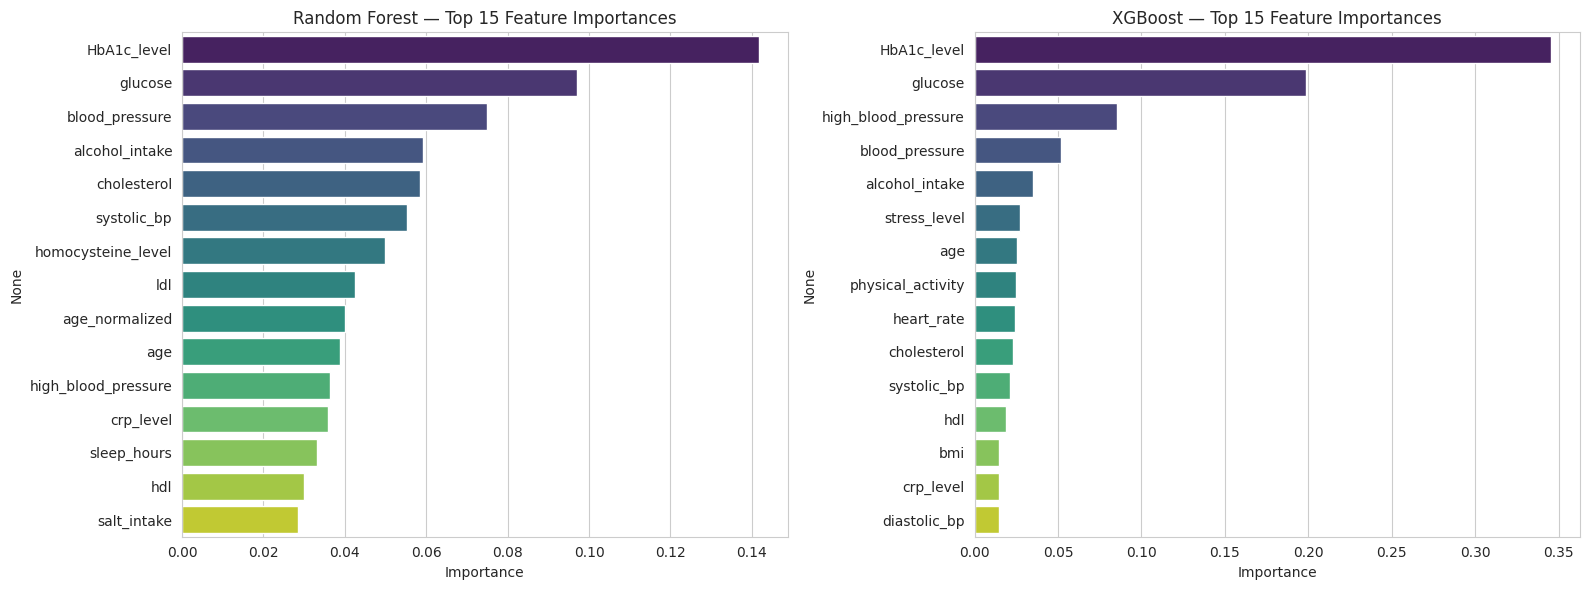

In [24]:
# Feature importance for tree-based models (useful for clinical interpretability)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, [("Random Forest", rf_clf), ("XGBoost", xgb_clf)]):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)
    sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")
    ax.set_title(f"{name} — Top 15 Feature Importances")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


## 8. Model Saving (Pickle)

We select the **winning model** based primarily on **recall** for the diabetic class (our
healthcare priority), using ROC-AUC as a tiebreaker. The winning model is persisted alongside the
fitted `StandardScaler` and the `LabelEncoder` dictionary, so a downstream **Streamlit** app can
load and apply the *exact same* preprocessing pipeline at inference time.


In [25]:
# Select the winning model: highest Recall (Class 1), tie-broken by ROC-AUC
best_model_name = summary_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Winning model selected: {best_model_name}")
print(summary_df.iloc[0])


Winning model selected: XGBoost
Model                  XGBoost
Precision (Class 1)        1.0
Recall (Class 1)           1.0
F1-score (Class 1)         1.0
ROC-AUC                    1.0
Name: 0, dtype: object


In [26]:
# Persist the winning model + scaler + encoders for deployment
artifact_bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "scaler": scaler,
    "label_encoders": label_encoders,
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "feature_order": list(X.columns),
}

OUTPUT_PATH = "diabetes_model_bundle.pkl"

with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(artifact_bundle, f)

print(f"Model bundle saved to '{OUTPUT_PATH}'.")
print("Bundle contents:")
for key in artifact_bundle:
    print(f"  - {key}")


Model bundle saved to 'diabetes_model_bundle.pkl'.
Bundle contents:
  - model
  - model_name
  - scaler
  - label_encoders
  - numerical_cols
  - categorical_cols
  - feature_order


In [27]:
# Sanity check: reload the pickle and confirm it predicts correctly
with open(OUTPUT_PATH, "rb") as f:
    loaded_bundle = pickle.load(f)

reloaded_model = loaded_bundle["model"]
reloaded_scaler = loaded_bundle["scaler"]

# Re-run a quick prediction on the existing scaled test set as a smoke test
sanity_preds = reloaded_model.predict(X_test_scaled)
sanity_auc = roc_auc_score(y_test, reloaded_model.predict_proba(X_test_scaled)[:, 1])

print(f"Reloaded model: {loaded_bundle['model_name']}")
print(f"Sanity-check ROC-AUC on test set: {sanity_auc:.4f}")
print("Model bundle successfully verified and ready for Streamlit deployment.")


Reloaded model: XGBoost
Sanity-check ROC-AUC on test set: 1.0000
Model bundle successfully verified and ready for Streamlit deployment.


## Summary & Next Steps

- Data was cleaned of leakage-prone and non-predictive columns before modeling.
- Three models were trained and benchmarked with an emphasis on **recall** for the positive
  (diabetic) class, given the healthcare screening context.
- The best-performing model, scaler, and encoders were bundled and pickled for deployment.

**Suggested next steps for a Streamlit app:**
1. Build an input form mapping to `feature_order` in the saved bundle.
2. Apply `label_encoders` to categorical inputs and `scaler` to numerical inputs before inference.
3. Display the predicted probability alongside the binary classification, with a clear medical
   disclaimer that this tool is not a substitute for professional diagnosis.
